# ML Problem Framing

The most common point of failure in enterprise Machine Learning does not occur during model training; it occurs before a single line of code is written. It happens when a business stakeholder asks a vague question, and the Data Scientist fails to translate that question into a rigorous mathematical optimization problem.

Machine Learning algorithms have no intuition. They do not understand "customer happiness," "business risk," or "engagement." They only understand **Feature Matrices ($X$)**, **Target Vectors ($y$)**, and minimizing mathematical loss. 

In this lesson, we will learn how to formally frame a business problem, mathematically define a target variable, establish a statistical baseline, and avoid the silent killer of ML projects: **Data Leakage**.

Before we touch an algorithm, we must define the universe in which our algorithm will operate. We do this by mapping the business reality to mathematical structures.

Let's set up our Python environment to simulate translating a real-world business problem—predicting customer churn for a SaaS platform—into a machine learning framework.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error

# Set professional visualization styling
sns.set_theme(style="whitegrid")

# Simulate a raw enterprise dataset of user activity
np.random.seed(42)
data = {
    'User_ID': range(1001, 1011),
    'Days_Since_Last_Login': [2, 45, 5, 80, 12, 60, 1, 90, 15, 3],
    'Total_Spend_USD': [120, 15, 200, 0, 50, 10, 300, 0, 80, 150],
    'Support_Tickets': [0, 3, 1, 5, 0, 2, 0, 4, 1, 0],
    'App_Crashes_Experienced': [0, 1, 0, 4, 0, 0, 0, 2, 0, 0]
}
df = pd.DataFrame(data)

print("✅ Raw Business Data Loaded.")
display(df.head())

✅ Raw Business Data Loaded.


,User_ID,Days_Since_Last_Login,Total_Spend_USD,Support_Tickets,App_Crashes_Experienced
0,1001,2,120,0,0
1,1002,45,15,3,1
2,1003,5,200,1,0
3,1004,80,0,5,4
4,1005,12,50,0,0


# 1. The Mathematical Formulation ($X$ and $y$)

In Supervised Learning, our goal is to approximate an unknown underlying function $f$ that maps our inputs to our outputs. We define our data structurally:

*   **The Feature Matrix ($X$)**: An $n \times m$ matrix where $n$ is the number of historical records (e.g., users) and $m$ is the number of predictive features (spend, tickets, crashes). Mathematically: $X \in \mathbb{R}^{n \times m}$.
*   **The Target Vector ($y$)**: An $n$-dimensional column vector containing the ground-truth historical outcomes we want to predict. Mathematically: $y \in \mathbb{R}^n$.

The objective of our future algorithms will be to find a hypothesis function $\hat{f}$ such that our predictions $\hat{y}$ are as close to the true $y$ as possible, minimizing an irreducible error $\epsilon$:
$$y = f(X) + \epsilon \approx \hat{y} = \hat{f}(X)$$

# 2. Translating Business into Target Variables ($y$)

A Product Manager comes to you and says: *"We need an AI to find users who are disengaged so we can send them a $20 promo code."*

"Disengaged" is a human concept; an algorithm cannot optimize for it. We must translate "Disengaged" into a mathematically observable **Target Variable**. We have two choices based on how we define the problem:

### Option A: Classification (Discrete Target)
We define "Disengaged" as a binary state. If a user has not logged in for $\ge 30$ days, they are churned ($y = 1$). Otherwise, they are active ($y = 0$).
$$y \in \{0, 1\}$$

### Option B: Regression (Continuous Target)
We define "Disengaged" as a continuous timeline. We predict the exact number of days until their next login.
$$y \in \mathbb{R}$$

Let us frame this mathematically as a **Classification** problem and extract our $X$ and $y$.

In [6]:
# The Business Rule translated to Math: Churn = No login for 30+ days.
churn_threshold = 30

# Derive the Target Vector (y)
df['y_Churn'] = (df['Days_Since_Last_Login'] >= churn_threshold).astype(int)

# Isolate the Feature Matrix (X) - dropping the ID and the data used to create 'y'
X = df[['Total_Spend_USD', 'Support_Tickets', 'App_Crashes_Experienced']]
y = df['y_Churn']

print("--- The Feature Matrix (X) ---")
display(X.head(3))
print("\n--- The Target Vector (y) ---")
display(y.head(3))

--- The Feature Matrix (X) ---


,Total_Spend_USD,Support_Tickets,App_Crashes_Experienced
0,120,0,0
1,15,3,1
2,200,1,0



--- The Target Vector (y) ---


0    0
1    1
2    0
Name: y_Churn, dtype: int64

# 3. Establishing the Statistical Baseline

Before you train a highly complex, computationally expensive model (like a Random Forest or a Neural Network), you must ask a critical question: *"What is the smartest 'dumb-guess' we can make using only basic statistics?"*

This is called the **Baseline Model**. If your advanced Machine Learning model cannot beat middle-school statistics, your model is financially useless and should not be deployed.

### The Classification Baseline (Majority Class)
For classification, the optimal naive strategy is to predict the mode (the most frequent class) for every single observation in the dataset, completely ignoring the Feature Matrix $X$.
$$\hat{y}_i = \text{mode}(y) \quad \text{for all } i$$

In [7]:
# 1. Find the Prior Probability (Distribution) of our classes
class_counts = y.value_counts(normalize=True)
majority_class = y.mode()[0]
baseline_accuracy = class_counts[majority_class]

print(f"--- Classification Baseline ---")
print(f"Majority Class: {majority_class} (Active)")
print(f"🚨 BASELINE ACCURACY: {baseline_accuracy * 100:.1f}%")
print("Insight: Because 60% of our users are Active, an algorithm that blindly guesses 'Active' for everyone will be right 60% of the time. Our ML model MUST exceed 60%.")

--- Classification Baseline ---
Majority Class: 0 (Active)
🚨 BASELINE ACCURACY: 60.0%
Insight: Because 60% of our users are Active, an algorithm that blindly guesses 'Active' for everyone will be right 60% of the time. Our ML model MUST exceed 60%.


### The Regression Baseline (Expected Value)
If we were predicting a continuous target (like `Total_Spend_USD`), our optimal naive strategy minimizes the Mean Squared Error by predicting the Expected Value (the arithmetic mean) of the target vector for every user.
$$\hat{y}_i = \mathbb{E}[y] = \frac{1}{n} \sum_{j=1}^{n} y_j \quad \text{for all } i$$

In [8]:
# 1. Define a continuous target
y_spend = df['Total_Spend_USD']

# 2. The Naive Baseline is the Mean
mean_spend = y_spend.mean()
baseline_spend_pred = np.full(shape=len(y_spend), fill_value=mean_spend)

# 3. Evaluate the Baseline mathematically
baseline_mae = mean_absolute_error(y_spend, baseline_spend_pred)
baseline_mse = mean_squared_error(y_spend, baseline_spend_pred)

print(f"\n--- Regression Baseline ---")
print(f"Mean Spend (Guess): ${mean_spend:.2f}")
print(f"🚨 BASELINE MAE: ${baseline_mae:.2f}")
print(f"🚨 BASELINE MSE: {baseline_mse:.1f}")
print(f"Insight: A naive guess is off by ${baseline_mae:.2f} on average. Our ML model must achieve an MAE lower than this.")


--- Regression Baseline ---
Mean Spend (Guess): $92.50
🚨 BASELINE MAE: $80.00
🚨 BASELINE MSE: 9056.2
Insight: A naive guess is off by $80.00 on average. Our ML model must achieve an MAE lower than this.


# 4. Data Leakage (Point-in-Time Correctness)

The most dangerous pitfall in ML problem framing is **Data Leakage**. This occurs when your Feature Matrix ($X$) contains information from the future that will not legitimately be available at the exact moment you need to make a prediction in production.

If your target $y$ is *"Did the user churn in Q2?"*, your feature matrix $X$ can only contain data generated up until `March 31st at 11:59:59 PM`. 

If $X$ accidentally contains a feature like `Q2_Total_Logins`, you have committed Target Leakage. The model will achieve 99.9% accuracy during training because the answer is literally inside the test. However, it will fail catastrophically in production because `Q2_Total_Logins` does not exist on April 1st.

### Visualizing Leakage
Let's plot a timeline to visualize what data is legally allowed inside $X$.

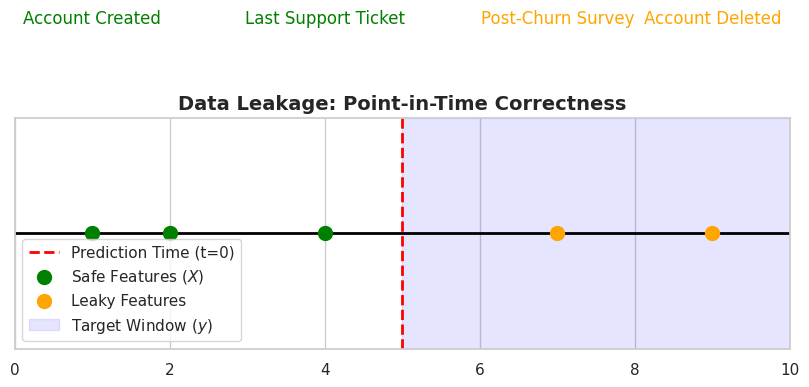

In [9]:
# Plotting a Point-in-Time Correctness Timeline
plt.figure(figsize=(10, 3))

# Draw the timeline
plt.hlines(1, 0, 10, colors='black', linewidth=2)

# Mark the Prediction Time
plt.axvline(5, color='red', linestyle='--', linewidth=2, label='Prediction Time (t=0)')

# Safe Features (Past)
plt.scatter([1, 2, 4], [1, 1, 1], color='green', s=100, zorder=5, label='Safe Features ($X$)')
plt.text(1, 1.1, 'Account Created', ha='center', color='green')
plt.text(4, 1.1, 'Last Support Ticket', ha='center', color='green')

# Leaky Features (Future)
plt.scatter([7, 9], [1, 1], color='orange', s=100, zorder=5, label='Leaky Features')
plt.text(7, 1.1, 'Post-Churn Survey', ha='center', color='orange')
plt.text(9, 1.1, 'Account Deleted', ha='center', color='orange')

# Target Window
plt.axvspan(5, 10, alpha=0.1, color='blue', label='Target Window ($y$)')

plt.title("Data Leakage: Point-in-Time Correctness", fontsize=14, fontweight='bold')
plt.xlim(0, 10)
plt.yticks([])
plt.legend(loc='lower left')
plt.show()

*(Insight: Everything to the left of the red line is safe to use in your Feature Matrix. Anything to the right of the red line is the future. If a single column in your dataset sneaks data from the right side to the left side, your model is contaminated and completely invalid.)*

## Real-World Use Case or Analogy:
Think of ML Problem Framing like **Underwriting a Corporate Insurance Policy**:

*   **The Business Problem**: The insurance company wants to "minimize financial risk." This is too vague.
*   **The Target Definition ($y$)**: The actuary translates the business problem into a mathematical target. They frame it as a regression problem: *"Predict the exact expected dollar amount ($y$) of claims this specific client will file in the next 365 days."*
*   **The Statistical Baseline**: Before looking at the client's specific medical history, the actuary calculates the national average. If the average citizen files $1,200 in claims a year, $1,200 is the baseline guess. 
*   **Data Leakage**: The actuary is predicting health costs for the year 2024. If they accidentally look at a hospital bill dated February 2024 while calculating their prediction on January 1st, they have committed Data Leakage. They are "cheating" by looking into the future. 
---